# RFM Segmentation Analysis
## Customer Segmentation using Recency, Frequency, Monetary Model

**Objective**: Segment customers based on purchasing behavior to identify:
- Champions (best customers)
- Loyal customers (repeat buyers)
- At-Risk customers (declining engagement)
- Lost customers (haven't purchased recently)

**Use Cases**:
- Targeted retention campaigns
- Personalized marketing strategies
- Resource allocation for customer success
- Churn prevention programs

In [9]:
import warnings
from datetime import timedelta

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Load processed fact table
fact_df = pd.read_csv('../data/processed/dwh/fact_order_items.csv')
customers_df = pd.read_csv('../data/processed/staging/raw_customers.csv')

print("="*80)
print("RFM SEGMENTATION ANALYSIS")
print("="*80)
print(f"\nFact table shape: {fact_df.shape}")
print(f"Customers table shape: {customers_df.shape}")

# Convert timestamp to datetime
fact_df['order_purchase_timestamp'] = pd.to_datetime(fact_df['order_purchase_timestamp'])
print("\n✓ Data loaded and prepared")

RFM SEGMENTATION ANALYSIS

Fact table shape: (112650, 25)
Customers table shape: (99441, 5)

✓ Data loaded and prepared


## 1. RFM METRICS CALCULATION

**Recency (R)**: Days since last purchase
- Interpretation: Recent customers are more likely to respond to campaigns
- Higher R value = Better (more recent)

**Frequency (F)**: Number of purchases
- Interpretation: Frequent buyers have higher lifetime value
- Higher F value = Better (more engaged)

**Monetary (M)**: Total amount spent
- Interpretation: High-spending customers drive revenue
- Higher M value = Better (more profitable)

In [10]:
# Calculate RFM metrics
print("\n" + "="*80)
print("CALCULATING RFM METRICS")
print("="*80)

# Reference date (current date)
reference_date = fact_df['order_purchase_timestamp'].max() + timedelta(days=1)
print(f"\nReference Date (for Recency calculation): {reference_date.date()}")
print(f"Data Date Range: {fact_df['order_purchase_timestamp'].min().date()} to {fact_df['order_purchase_timestamp'].max().date()}")

# Filter only delivered orders
fact_delivered = fact_df[fact_df['order_status'] == 'delivered'].copy()

# Group by customer
rfm = fact_delivered.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (reference_date - x.max()).days,  # Recency
    'order_id': 'nunique',  # Frequency
    'total_value': 'sum'     # Monetary
}).rename(columns={
    'order_purchase_timestamp': 'recency_days',
    'order_id': 'frequency',
    'total_value': 'monetary'
}).reset_index()

# Add customer location information
rfm = rfm.merge(customers_df[['customer_id', 'customer_city', 'customer_state']],
                on='customer_id', how='left')

print(f"\nRFM Metrics Calculated for {len(rfm)} unique customers")
print("\n" + "-"*80)
print("RFM DISTRIBUTION STATISTICS")
print("-"*80)

for metric in ['recency_days', 'frequency', 'monetary']:
    print(f"\n{metric.upper()}:")
    print(f"  Mean:    {rfm[metric].mean():>10.2f}")
    print(f"  Median:  {rfm[metric].median():>10.2f}")
    print(f"  Min:     {rfm[metric].min():>10.2f}")
    print(f"  Max:     {rfm[metric].max():>10.2f}")
    print(f"  Std:     {rfm[metric].std():>10.2f}")

# Display sample
print("\n" + "-"*80)
print("SAMPLE RFM DATA (Top 10 by Monetary)")
print("-"*80)
print(rfm.nlargest(10, 'monetary')[['customer_id', 'recency_days', 'frequency', 'monetary']].to_string(index=False))


CALCULATING RFM METRICS

Reference Date (for Recency calculation): 2018-09-04
Data Date Range: 2016-09-04 to 2018-09-03

RFM Metrics Calculated for 96478 unique customers

--------------------------------------------------------------------------------
RFM DISTRIBUTION STATISTICS
--------------------------------------------------------------------------------

RECENCY_DAYS:
  Mean:        244.76
  Median:      226.00
  Min:           5.00
  Max:         718.00
  Std:         152.84

FREQUENCY:
  Mean:          1.00
  Median:        1.00
  Min:           1.00
  Max:           1.00
  Std:           0.00

MONETARY:
  Mean:        159.83
  Median:      105.28
  Min:           9.59
  Max:       13664.08
  Std:         218.79

--------------------------------------------------------------------------------
SAMPLE RFM DATA (Top 10 by Monetary)
--------------------------------------------------------------------------------
                     customer_id  recency_days  frequency  monetary
1

## 2. RFM SCORING (Quartile-based)

Using quartile binning to assign R, F, M scores (1-4):
- Score 4: Top quartile (best)
- Score 3: 2nd quartile
- Score 2: 3rd quartile  
- Score 1: Bottom quartile (worst)

Note: For Recency, LOWER is better (more recent), so scoring is inverted

In [11]:
# Assign RFM scores using quartiles
print("\n" + "="*80)
print("ASSIGNING RFM SCORES (Quartile-based)")
print("="*80)

# Recency: Lower is better, so invert the scoring
# (customers who bought recently get higher score)
rfm['r_score'] = pd.qcut(rfm['recency_days'], q=4, labels=[4, 3, 2, 1], duplicates='drop').astype(int)

# Frequency: Higher is better
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4], duplicates='drop').astype(int)

# Monetary: Higher is better
rfm['m_score'] = pd.qcut(rfm['monetary'], q=4, labels=[1, 2, 3, 4], duplicates='drop').astype(int)

# Combined RFM score (average of the three)
rfm['rfm_score'] = rfm[['r_score', 'f_score', 'm_score']].mean(axis=1).round(2)

print("\n✓ RFM Scores Assigned")
print("\nR_SCORE (Recency) Distribution:")
print(rfm['r_score'].value_counts().sort_index(ascending=False))
print("\nF_SCORE (Frequency) Distribution:")
print(rfm['f_score'].value_counts().sort_index())
print("\nM_SCORE (Monetary) Distribution:")
print(rfm['m_score'].value_counts().sort_index())


ASSIGNING RFM SCORES (Quartile-based)

✓ RFM Scores Assigned

R_SCORE (Recency) Distribution:
r_score
4    24244
3    24110
2    24004
1    24120
Name: count, dtype: int64

F_SCORE (Frequency) Distribution:
f_score
1    24120
2    24119
3    24119
4    24120
Name: count, dtype: int64

M_SCORE (Monetary) Distribution:
m_score
1    24126
2    24173
3    24060
4    24119
Name: count, dtype: int64


## 3. CUSTOMER SEGMENTATION

Business-meaningful segments based on RFM scores:

In [ ]:
# Segment customers based on RFM scores
print("\n" + "="*80)
print("CUSTOMER SEGMENTATION")
print("="*80)

def segment_customer(r, f, m):
    """Assign customer to segment based on RFM scores"""

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 4 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f >= 3 and m >= 3:
        return 'Potential Loyalists'
    elif r >= 4 and f <= 2 and m <= 2:
        return 'New Customers'
    elif r <= 2 and f >= 4 and m >= 4:
        return 'At Risk'
    elif r <= 2 and f >= 3 and m >= 2:
        return 'Need Attention'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost'
    else:
        return 'Other'

rfm['segment'] = rfm.apply(lambda x: segment_customer(x['r_score'], x['f_score'], x['m_score']), axis=1)

# Segment statistics
print("\nSEGMENT DISTRIBUTION:")
print("-"*80)
segment_stats = rfm.groupby('segment').agg({
    'customer_id': 'count',
    'recency_days': 'mean',
    'frequency': 'mean',
    'monetary': ['mean', 'sum'],
    'rfm_score': 'mean'
}).round(2)

segment_stats.columns = ['customer_count', 'avg_recency_days', 'avg_frequency',
                         'avg_monetary', 'total_monetary', 'avg_rfm_score']

# Calculate percentages
segment_stats['pct_customers'] = (segment_stats['customer_count'] / segment_stats['customer_count'].sum() * 100).round(1)
segment_stats['pct_revenue'] = (segment_stats['total_monetary'] / segment_stats['total_monetary'].sum() * 100).round(1)

# Sort by revenue contribution
segment_stats = segment_stats.sort_values('total_monetary', ascending=False)

print(segment_stats.to_string())

print("\n" + "-"*80)
print("SEGMENT BUSINESS STRATEGY:")
print("-"*80)
strategies = {
    'Champions': '🏆 VIP Treatment - Retain and upsell',
    'Loyal Customers': '👑 Reward loyalty - Increase basket size',
    'Potential Loyalists': '📈 Nurture - Convert to loyal',
    'New Customers': '🎯 Onboard - Encourage repeat purchase',
    'At Risk': '⚠️ Win back - Special offers',
    'Need Attention': '💛 Engage - Personalized campaigns',
    'Lost': '🔄 Reactivate - Win back campaigns',
    'Other': '📊 Monitor - Observe behavior'
}

for segment in segment_stats.index:
    if segment in strategies:
        print(f"{segment:20s}: {strategies[segment]}")


CUSTOMER SEGMENTATION

SEGMENT DISTRIBUTION:
--------------------------------------------------------------------------------
                     customer_count  avg_recency_days  avg_frequency  avg_monetary  total_monetary  avg_rfm_score  pct_customers  pct_revenue
segment                                                                                                                                      
Other                         50950            217.61            1.0        163.47      8329047.13           2.50           52.8         54.0
Need Attention                15074            370.17            1.0        162.10      2443514.98           2.56           15.6         15.8
At Risk                        2957            369.76            1.0        382.28      1130405.55           3.17            3.1          7.3
Loyal Customers                4651            136.75            1.0        210.43       978711.48           3.56            4.8          6.3
Potential Loyalists  

## 4. RFM VISUALIZATION & INSIGHTS

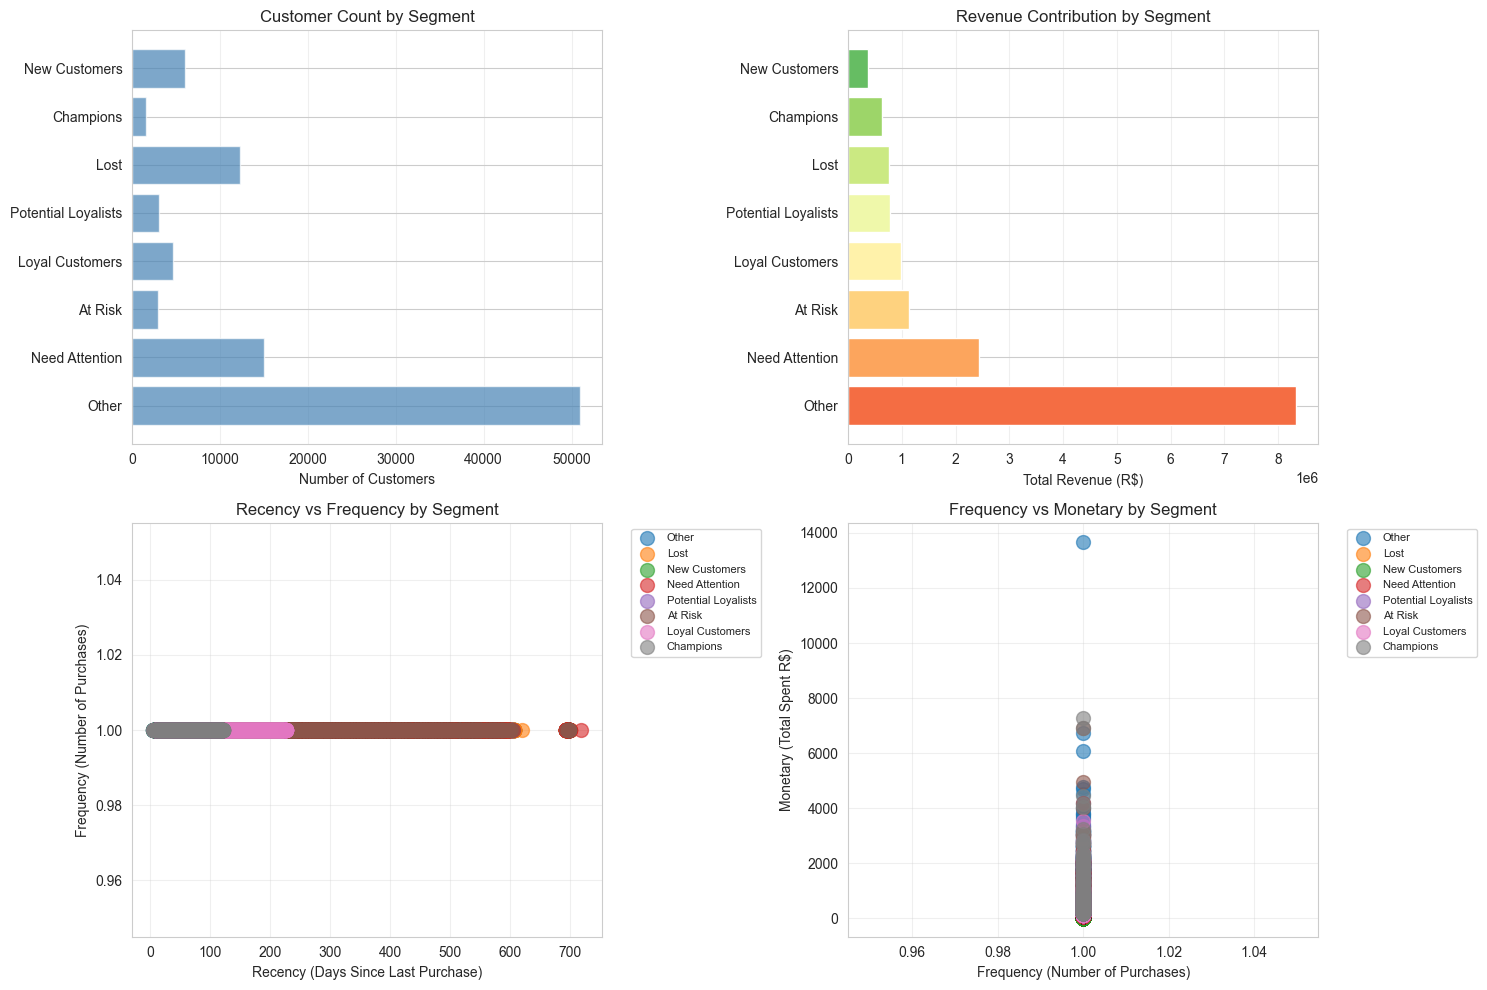


✓ Visualizations saved to reports/rfm_segmentation_analysis.png


In [13]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Segment distribution (count vs revenue)
ax1 = axes[0, 0]
segment_order = rfm.groupby('segment')['monetary'].sum().sort_values(ascending=False).index
seg_count = rfm['segment'].value_counts().reindex(segment_order)
ax1.barh(range(len(seg_count)), seg_count.values, color='steelblue', alpha=0.7)
ax1.set_yticks(range(len(seg_count)))
ax1.set_yticklabels(seg_count.index)
ax1.set_xlabel('Number of Customers')
ax1.set_title('Customer Count by Segment')
ax1.grid(axis='x', alpha=0.3)

# 2. Revenue by segment
ax2 = axes[0, 1]
seg_revenue = rfm.groupby('segment')['monetary'].sum().reindex(segment_order)
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(seg_revenue)))
ax2.barh(range(len(seg_revenue)), seg_revenue.values, color=colors)
ax2.set_yticks(range(len(seg_revenue)))
ax2.set_yticklabels(seg_revenue.index)
ax2.set_xlabel('Total Revenue (R$)')
ax2.set_title('Revenue Contribution by Segment')
ax2.grid(axis='x', alpha=0.3)

# 3. Recency vs Frequency (scatter plot colored by segment)
ax3 = axes[1, 0]
for segment in rfm['segment'].unique():
    segment_data = rfm[rfm['segment'] == segment]
    ax3.scatter(segment_data['recency_days'], segment_data['frequency'],
                label=segment, alpha=0.6, s=100)
ax3.set_xlabel('Recency (Days Since Last Purchase)')
ax3.set_ylabel('Frequency (Number of Purchases)')
ax3.set_title('Recency vs Frequency by Segment')
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax3.grid(True, alpha=0.3)

# 4. Monetary vs Frequency
ax4 = axes[1, 1]
for segment in rfm['segment'].unique():
    segment_data = rfm[rfm['segment'] == segment]
    ax4.scatter(segment_data['frequency'], segment_data['monetary'],
                label=segment, alpha=0.6, s=100)
ax4.set_xlabel('Frequency (Number of Purchases)')
ax4.set_ylabel('Monetary (Total Spent R$)')
ax4.set_title('Frequency vs Monetary by Segment')
ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/rfm_segmentation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualizations saved to reports/rfm_segmentation_analysis.png")

## 5. KEY INSIGHTS & BUSINESS ACTIONS

### Insight Summary

This section will be populated with specific findings once data is analyzed:

In [14]:
# Generate key insights
print("\n" + "="*80)
print("KEY BUSINESS INSIGHTS")
print("="*80)

# 1. Revenue concentration
top_segment_revenue_pct = segment_stats['pct_revenue'].iloc[0]
top_segment_customer_pct = segment_stats['pct_customers'].iloc[0]
print("\n1. REVENUE CONCENTRATION (Pareto Analysis)")
print(f"   Top segment ({segment_stats.index[0]}) has:")
print(f"   - {top_segment_customer_pct}% of customers")
print(f"   - {top_segment_revenue_pct}% of revenue")
print("   💡 Action: Prioritize retention of high-value segments")

# 2. At-risk customers
at_risk = rfm[rfm['segment'] == 'At Risk']
if len(at_risk) > 0:
    at_risk_revenue = at_risk['monetary'].sum()
    print("\n2. AT-RISK SEGMENT")
    print(f"   - {len(at_risk)} customers ({len(at_risk)/len(rfm)*100:.1f}% of base)")
    print(f"   - Potential revenue at stake: R$ {at_risk_revenue:,.2f}")
    print("   💡 Action: Launch win-back campaign with special offers")

# 3. New customers
new_customers = rfm[rfm['segment'] == 'New Customers']
if len(new_customers) > 0:
    print("\n3. NEW CUSTOMER ONBOARDING")
    print(f"   - {len(new_customers)} customers ({len(new_customers)/len(rfm)*100:.1f}% of base)")
    print(f"   - Average CLV: R$ {new_customers['monetary'].mean():.2f}")
    print("   💡 Action: Implement onboarding program to drive repeat purchase")

# 4. Loyalty metrics
repeat_pct = (len(rfm[rfm['frequency'] > 1]) / len(rfm) * 100)
print("\n4. LOYALTY METRICS")
print(f"   - Repeat purchase rate: {repeat_pct:.1f}%")
print(f"   - Average customer value: R$ {rfm['monetary'].mean():.2f}")
print(f"   💡 Action: Target is >30% repeat rate; current status: {'✓ GOOD' if repeat_pct > 30 else '✗ NEEDS IMPROVEMENT'}")

# Save RFM results
rfm_export = rfm[['customer_id', 'recency_days', 'frequency', 'monetary',
                   'r_score', 'f_score', 'm_score', 'rfm_score', 'segment',
                   'customer_city', 'customer_state']]
rfm_export.to_csv('../data/processed/rfm_segmentation.csv', index=False)

print("\n✓ RFM segmentation exported to data/processed/rfm_segmentation.csv")
print(f"   Total customers segmented: {len(rfm_export)}")


KEY BUSINESS INSIGHTS

1. REVENUE CONCENTRATION (Pareto Analysis)
   Top segment (Other) has:
   - 52.8% of customers
   - 54.0% of revenue
   💡 Action: Prioritize retention of high-value segments

2. AT-RISK SEGMENT
   - 2957 customers (3.1% of base)
   - Potential revenue at stake: R$ 1,130,405.55
   💡 Action: Launch win-back campaign with special offers

3. NEW CUSTOMER ONBOARDING
   - 6000 customers (6.2% of base)
   - Average CLV: R$ 62.10
   💡 Action: Implement onboarding program to drive repeat purchase

4. LOYALTY METRICS
   - Repeat purchase rate: 0.0%
   - Average customer value: R$ 159.83
   💡 Action: Target is >30% repeat rate; current status: ✗ NEEDS IMPROVEMENT

✓ RFM segmentation exported to data/processed/rfm_segmentation.csv
   Total customers segmented: 96478
